# Preliminary Anvil profile evaluation

This notebook compares two OpenAI models across three retrieval modes using the same frozen
documentation corpus, login measurements, and pilot results.

The ground truth is still marked `unreviewed`, so every accuracy result is **provisional**.
For this preliminary analysis, `silent` and `not_applicable` are merged into one
**expected absence** class. String comparisons are case-insensitive; numeric and Boolean
comparisons remain typed; `set` comparisons ignore order.

In [1]:
from collections import Counter
from hashlib import sha256
from pathlib import Path
import json
import re

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Run the notebook from inside the HPC Site Preflight repository.")


ROOT = find_repo_root(Path.cwd().resolve())
RESULT_ROOT = ROOT / "artifacts/evaluation/anvil"
GROUND_TRUTH_PATH = ROOT / "evaluation/ground-truth/partial-anvil-site-profile.csv"
CORPUS_DIR = ROOT / "examples/simulate/anvil/corpus"
MEASUREMENTS_PATH = ROOT / "examples/simulate/anvil/login-measurements.json"
PILOT_PATH = ROOT / "examples/simulate/anvil/pilot-result.json"
ANALYSIS_DIR = RESULT_ROOT / "preliminary-analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

MODELS = {
    "gpt-5-mini": "GPT-5 Mini",
    "gpt-5.6-terra": "GPT-5.6 Terra",
}
MODES = {
    "full-corpus": "Full corpus",
    "bm25": "BM25",
    "llm-expanded-bm25": "LLM-expanded BM25",
}
RUN_ORDER = [(model, mode) for model in MODELS for mode in MODES]
COLORS = {"GPT-5 Mini": "#4C78A8", "GPT-5.6 Terra": "#F58518"}

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def file_hash(path: Path) -> str:
    return sha256(path.read_bytes()).hexdigest()


print(f"Repository: {ROOT}")
print(f"Analysis output: {ANALYSIS_DIR}")

Repository: /Users/saiful/ai-projects/hpc-site-preflight
Analysis output: /Users/saiful/ai-projects/hpc-site-preflight/artifacts/evaluation/anvil/preliminary-analysis


## 1. Load and verify the six runs

Each run must be completed, use the same frozen corpus fingerprint and pilot result, and contain
no web tool calls. If a run directory contains several attempts, the most recently started
performance record is selected and its run ID is displayed.

In [2]:
def load_runs() -> dict:
    loaded = {}
    for model, mode in RUN_ORDER:
        base = RESULT_ROOT / model / mode / "run-01"
        output = base / "output"
        performance_paths = list((base / "runs").glob("*/performance.json"))
        if not performance_paths:
            raise FileNotFoundError(f"No performance result for {model} / {mode}")
        performance_records = [read_json(path) for path in performance_paths]
        performance = max(performance_records, key=lambda item: item["started_at"])
        loaded[(model, mode)] = {
            "performance": performance,
            "profile": read_json(output / "site-profile.json"),
            "documentation": read_json(output / "documentation-evidence.json"),
            "evidence": read_json(output / "evidence-report.json"),
            "pilot": read_json(output / "pilot-evidence.json"),
        }
    return loaded


runs = load_runs()
integrity_rows = []
for (model, mode), run in runs.items():
    performance = run["performance"]
    documentation = run["documentation"]
    integrity_rows.append({
        "model": MODELS[model],
        "mode": MODES[mode],
        "run_id": performance["run_id"],
        "status": performance["status"],
        "corpus_fingerprint": documentation["corpus_fingerprint"],
        "pilot_id": run["pilot"]["pilot_id"],
        "site_id": run["profile"]["site_id"],
        "web_tool_calls": performance["tool_calls"],
    })

integrity = pd.DataFrame(integrity_rows)
display(integrity)

assert set(integrity["status"]) == {"completed"}
assert integrity["corpus_fingerprint"].nunique() == 1
assert integrity["pilot_id"].nunique() == 1
assert integrity["site_id"].nunique() == 1
assert set(integrity["web_tool_calls"]) == {0}

input_hashes = pd.DataFrame([
    {"input": "login measurements", "sha256": file_hash(MEASUREMENTS_PATH)},
    {"input": "pilot result", "sha256": file_hash(PILOT_PATH)},
    {"input": "corpus manifest", "sha256": file_hash(CORPUS_DIR / "manifest.json")},
    {"input": "corpus documents", "sha256": file_hash(CORPUS_DIR / "documents.jsonl")},
    {"input": "corpus chunks", "sha256": file_hash(CORPUS_DIR / "chunks.jsonl")},
])
display(input_hashes)

,model,mode,run_id,status,corpus_fingerprint,pilot_id,site_id,web_tool_calls
0,GPT-5 Mini,Full corpus,dec0c28b-b5a0-40d7-8f48-bc00dd6173d3,completed,92e269282edacb5fb32b139ae6d55bc539ef886e1edcbb...,7a1036ad15d941149f86297aa2b5379a,anvil,0
1,GPT-5 Mini,BM25,e322117d-c2e6-4840-94db-11dd3134ff6c,completed,92e269282edacb5fb32b139ae6d55bc539ef886e1edcbb...,7a1036ad15d941149f86297aa2b5379a,anvil,0
2,GPT-5 Mini,LLM-expanded BM25,dc468d51-79ca-40f0-a3f6-3d798d22488a,completed,92e269282edacb5fb32b139ae6d55bc539ef886e1edcbb...,7a1036ad15d941149f86297aa2b5379a,anvil,0
3,GPT-5.6 Terra,Full corpus,d510f42b-ff2e-4c17-a33a-6845392bf63b,completed,92e269282edacb5fb32b139ae6d55bc539ef886e1edcbb...,7a1036ad15d941149f86297aa2b5379a,anvil,0
4,GPT-5.6 Terra,BM25,d14b7af7-d727-420f-9a8d-0508582b06e7,completed,92e269282edacb5fb32b139ae6d55bc539ef886e1edcbb...,7a1036ad15d941149f86297aa2b5379a,anvil,0
5,GPT-5.6 Terra,LLM-expanded BM25,f5672f54-271f-4ac9-a12f-5c482f3ae63d,completed,92e269282edacb5fb32b139ae6d55bc539ef886e1edcbb...,7a1036ad15d941149f86297aa2b5379a,anvil,0


,input,sha256
0,login measurements,d6b72c003c16996ca88d9ead54d0d58662b945836ff993...
1,pilot result,886132649cc61567e78306b47b5313b596880532a9a100...
2,corpus manifest,9096b93688785ca57490afaafdf50dc7f749ebcde7dcb6...
3,corpus documents,e7195defd42eff945e86ceaa1114fa03cd4f51e86208b0...
4,corpus chunks,8ed81f7b59d075ae61197d56aa2b3324222d66e62f1314...


## 2. Performance

Provider-reported tokens are used directly. Model latency is the sum of
`structured_model_call` stage durations; total latency covers the complete profile build,
including deterministic measurement/profile/pilot stages.

In [3]:
performance_rows = []
for (model, mode), run in runs.items():
    performance = run["performance"]
    usage = performance["model_usage"]
    model_seconds = sum(
        step["duration_seconds"]
        for step in performance["steps"]
        if step["name"] == "structured_model_call"
    )
    performance_rows.append({
        "model": MODELS[model],
        "mode": MODES[mode],
        "run_id": performance["run_id"],
        "total_seconds": performance["duration_seconds"],
        "model_seconds": model_seconds,
        "model_calls": usage["requests"],
        "input_tokens": usage["input_tokens"],
        "output_tokens": usage["output_tokens"],
        "total_tokens": usage["total_tokens"],
        "retries": performance["retries"],
    })

performance_df = pd.DataFrame(performance_rows)
performance_df["model"] = pd.Categorical(
    performance_df["model"], list(MODELS.values()), ordered=True
)
performance_df["mode"] = pd.Categorical(
    performance_df["mode"], list(MODES.values()), ordered=True
)
performance_df = performance_df.sort_values(["model", "mode"]).reset_index(drop=True)
performance_df.to_csv(ANALYSIS_DIR / "run-summary.csv", index=False)
display(performance_df)

,model,mode,run_id,total_seconds,model_seconds,model_calls,input_tokens,output_tokens,total_tokens,retries
0,GPT-5 Mini,Full corpus,dec0c28b-b5a0-40d7-8f48-bc00dd6173d3,594.417469,594.203137,13,53923,39612,93535,0
1,GPT-5 Mini,BM25,e322117d-c2e6-4840-94db-11dd3134ff6c,173.140333,172.838170,5,11902,13168,25070,0
2,GPT-5 Mini,LLM-expanded BM25,dc468d51-79ca-40f0-a3f6-3d798d22488a,174.151425,173.675802,6,16787,10584,27371,0
3,GPT-5.6 Terra,Full corpus,d510f42b-ff2e-4c17-a33a-6845392bf63b,46.600143,46.390329,14,58084,3513,61597,0
4,GPT-5.6 Terra,BM25,d14b7af7-d727-420f-9a8d-0508582b06e7,18.789626,18.547669,4,8822,1700,10522,0
5,GPT-5.6 Terra,LLM-expanded BM25,f5672f54-271f-4ac9-a12f-5c482f3ae63d,19.911615,19.510458,4,9391,1687,11078,0


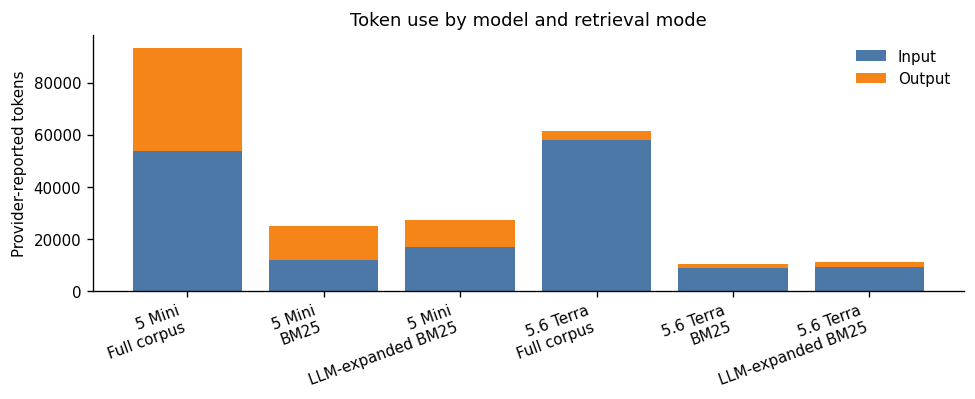

In [4]:
labels = [
    f"{row.model.replace('GPT-', '')}\n{row.mode}"
    for row in performance_df.itertuples()
]
x = range(len(performance_df))

fig, ax = plt.subplots(figsize=(8.2, 3.4))
ax.bar(x, performance_df["input_tokens"], label="Input", color="#4C78A8")
ax.bar(
    x,
    performance_df["output_tokens"],
    bottom=performance_df["input_tokens"],
    label="Output",
    color="#F58518",
)
ax.set_xticks(list(x), labels, rotation=20, ha="right")
ax.set_ylabel("Provider-reported tokens")
ax.set_title("Token use by model and retrieval mode")
ax.legend(frameon=False)
fig.tight_layout()
pdf_path = ANALYSIS_DIR / "token-usage.pdf"
png_path = ANALYSIS_DIR / "token-usage.png"
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(png_path)))

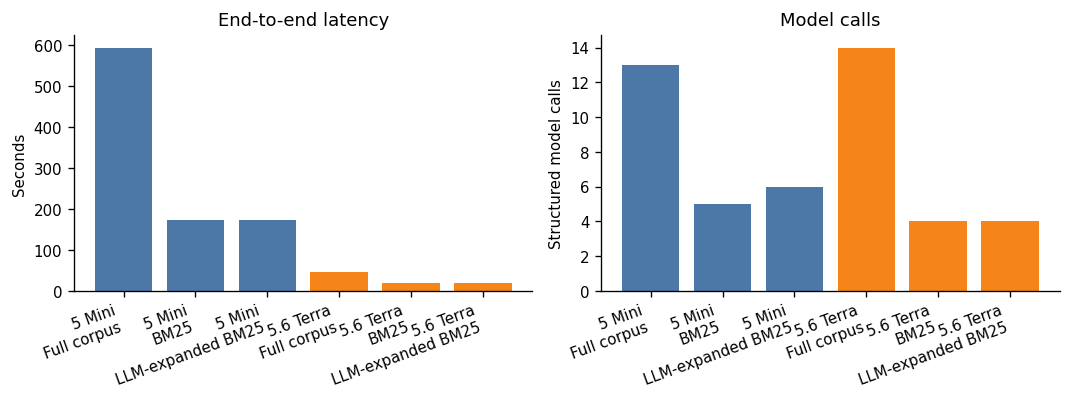

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
bar_colors = [COLORS[str(model)] for model in performance_df["model"]]

axes[0].bar(x, performance_df["total_seconds"], color=bar_colors)
axes[0].set_xticks(list(x), labels, rotation=20, ha="right")
axes[0].set_ylabel("Seconds")
axes[0].set_title("End-to-end latency")

axes[1].bar(x, performance_df["model_calls"], color=bar_colors)
axes[1].set_xticks(list(x), labels, rotation=20, ha="right")
axes[1].set_ylabel("Structured model calls")
axes[1].set_title("Model calls")

fig.tight_layout()
pdf_path = ANALYSIS_DIR / "latency-and-model-calls.pdf"
png_path = ANALYSIS_DIR / "latency-and-model-calls.png"
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(png_path)))

## 3. Provisional field evaluation

Named profile arrays are converted into addressable paths before comparison. For example,
the `account` element of `slurm.options` becomes `/slurm/options/account/...`.

Outcomes:

- **correct value**: populated and matches the expected value;
- **incorrect value**: populated but disagrees with an expected value;
- **missing value**: expected value but profile abstained;
- **correct absence**: ground truth is `silent` or `not_applicable`, and profile is absent;
- **unexpected value**: ground truth is `silent` or `not_applicable`, but profile populated it.

Incorrect values count against both precision and recall. `silent` and `not_applicable` are
intentionally merged only for this preliminary analysis.

In [6]:
MISSING = object()


def named(items: list[dict], key: str = "name") -> dict:
    return {item[key]: item for item in items or []}


def flatten_profile(profile: dict) -> dict:
    values = {
        "/aliases": profile.get("aliases"),
        "/scheduler_type": profile.get("scheduler_type"),
        "/scheduler_version": profile.get("scheduler_version"),
        "/htcondor": profile.get("htcondor"),
    }

    slurm = profile.get("slurm") or {}
    options = named(slurm.get("options", []))
    partitions = named(slurm.get("partitions", []))
    values["/slurm/submit_command"] = slurm.get("submit_command")
    values["/slurm/options"] = list(options)
    values["/slurm/unmapped_options"] = slurm.get("unmapped_options", [])
    for option_name, option in options.items():
        for field in ("syntax", "required", "allowed_values"):
            values[f"/slurm/options/{option_name}/{field}"] = option.get(field)
    values["/slurm/partitions"] = list(partitions)
    for partition_name, partition in partitions.items():
        for field in (
            "available",
            "maximum_walltime_seconds",
            "node_count",
            "cpus_per_node",
            "memory_mib_per_node",
            "temporary_disk_mib_per_node",
            "gpu_count_per_node",
            "gpu_models",
            "features",
        ):
            values[f"/slurm/partitions/{partition_name}/{field}"] = partition.get(field)

    storage = named(profile.get("storage", []))
    values["/storage"] = list(storage)
    for storage_name, item in storage.items():
        for field in (
            "path_pattern",
            "filesystem_type",
            "login_readable",
            "login_writable",
            "compute_visible",
            "compute_readable",
            "compute_writable",
            "available_bytes",
            "purge_after_days",
        ):
            values[f"/storage/{storage_name}/{field}"] = item.get(field)

    network = profile.get("network", {})
    for section in ("login", "compute", "login_compute", "compute_compute"):
        for field, value in network.get(section, {}).items():
            values[f"/network/{section}/{field}"] = value

    for section in ("accounting", "software"):
        for field, value in profile.get(section, {}).items():
            values[f"/{section}/{field}"] = value
    return values


def parse_json_cell(value):
    if pd.isna(value) or str(value).strip() == "":
        return MISSING
    return json.loads(str(value))


def normalize(value):
    if isinstance(value, str):
        return re.sub(r"\s+", " ", value).strip().casefold()
    if isinstance(value, list):
        return [normalize(item) for item in value]
    if isinstance(value, dict):
        return {key.casefold(): normalize(item) for key, item in sorted(value.items())}
    return value


def is_absent(value) -> bool:
    return (
        value is MISSING
        or value is None
        or value == ""
        or value == []
        or value == {}
    )


def values_match(actual, expected, rule: str) -> bool:
    actual = normalize(actual)
    expected = normalize(expected)
    if rule == "set":
        if not isinstance(actual, list) or not isinstance(expected, list):
            return False
        encode = lambda item: json.dumps(item, sort_keys=True, ensure_ascii=False)
        return {encode(item) for item in actual} == {encode(item) for item in expected}
    return actual == expected


def render_value(value) -> str:
    if value is MISSING:
        return ""
    return json.dumps(value, ensure_ascii=False, sort_keys=True)


truth = pd.read_csv(GROUND_TRUTH_PATH, dtype=str, keep_default_na=False)
truth["expected_class"] = truth["expected_state"].map(
    lambda state: "value" if state == "value" else "absence"
)
print("Ground-truth rows:", len(truth))
print("Review status:", truth["review_status"].value_counts().to_dict())
print("Expected classes:", truth["expected_class"].value_counts().to_dict())

Ground-truth rows: 191
Review status: {'unreviewed': 191}
Expected classes: {'value': 111, 'absence': 80}


In [7]:
field_rows = []
metric_rows = []
for model, mode in RUN_ORDER:
    actual = flatten_profile(runs[(model, mode)]["profile"])
    outcomes = Counter()
    for row in truth.to_dict(orient="records"):
        expected = parse_json_cell(row["expected_value_json"])
        observed = actual.get(row["field_path"], MISSING)
        if row["expected_class"] == "absence":
            outcome = "correct_absence" if is_absent(observed) else "unexpected_value"
        elif is_absent(observed):
            outcome = "missing_value"
        elif values_match(observed, expected, row["match_rule"]):
            outcome = "correct_value"
        else:
            outcome = "incorrect_value"
        outcomes[outcome] += 1
        field_rows.append({
            "model": MODELS[model],
            "mode": MODES[mode],
            "field_path": row["field_path"],
            "section": row["section"],
            "expected_state": row["expected_state"],
            "expected_class": row["expected_class"],
            "expected_value_json": row["expected_value_json"],
            "actual_value_json": render_value(observed),
            "match_rule": row["match_rule"],
            "outcome": outcome,
            "review_status": row["review_status"],
        })

    true_positive = outcomes["correct_value"]
    incorrect = outcomes["incorrect_value"]
    unsupported = outcomes["unexpected_value"]
    expected_values = sum(truth["expected_class"] == "value")
    expected_absence = sum(truth["expected_class"] == "absence")
    predicted_values = true_positive + incorrect + unsupported
    precision = true_positive / predicted_values if predicted_values else 0.0
    recall = true_positive / expected_values if expected_values else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    abstention_accuracy = (
        outcomes["correct_absence"] / expected_absence if expected_absence else 0.0
    )
    field_accuracy = (
        outcomes["correct_value"] + outcomes["correct_absence"]
    ) / len(truth)
    metric_rows.append({
        "model": MODELS[model],
        "mode": MODES[mode],
        **outcomes,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "abstention_accuracy": abstention_accuracy,
        "field_accuracy": field_accuracy,
    })

field_df = pd.DataFrame(field_rows)
metrics_df = pd.DataFrame(metric_rows)
for outcome in (
    "correct_value",
    "incorrect_value",
    "missing_value",
    "correct_absence",
    "unexpected_value",
):
    if outcome not in metrics_df:
        metrics_df[outcome] = 0
    metrics_df[outcome] = metrics_df[outcome].fillna(0).astype(int)
metrics_df["model"] = pd.Categorical(
    metrics_df["model"], list(MODELS.values()), ordered=True
)
metrics_df["mode"] = pd.Categorical(
    metrics_df["mode"], list(MODES.values()), ordered=True
)
metrics_df = metrics_df.sort_values(["model", "mode"]).reset_index(drop=True)

field_df.to_csv(ANALYSIS_DIR / "field-evaluation.csv", index=False)
metrics_df.to_csv(ANALYSIS_DIR / "mode-metrics.csv", index=False)
display(metrics_df)

,model,mode,missing_value,correct_value,unexpected_value,correct_absence,incorrect_value,precision,recall,f1,abstention_accuracy,field_accuracy
0,GPT-5 Mini,Full corpus,28,81,13,67,2,0.843750,0.729730,0.782609,0.8375,0.774869
1,GPT-5 Mini,BM25,27,83,10,70,1,0.882979,0.747748,0.809756,0.8750,0.801047
2,GPT-5 Mini,LLM-expanded BM25,27,82,13,67,2,0.845361,0.738739,0.788462,0.8375,0.780105
3,GPT-5.6 Terra,Full corpus,28,82,10,70,1,0.881720,0.738739,0.803922,0.8750,0.795812
4,GPT-5.6 Terra,BM25,29,82,9,71,0,0.901099,0.738739,0.811881,0.8875,0.801047
5,GPT-5.6 Terra,LLM-expanded BM25,28,82,9,71,1,0.891304,0.738739,0.807882,0.8875,0.801047


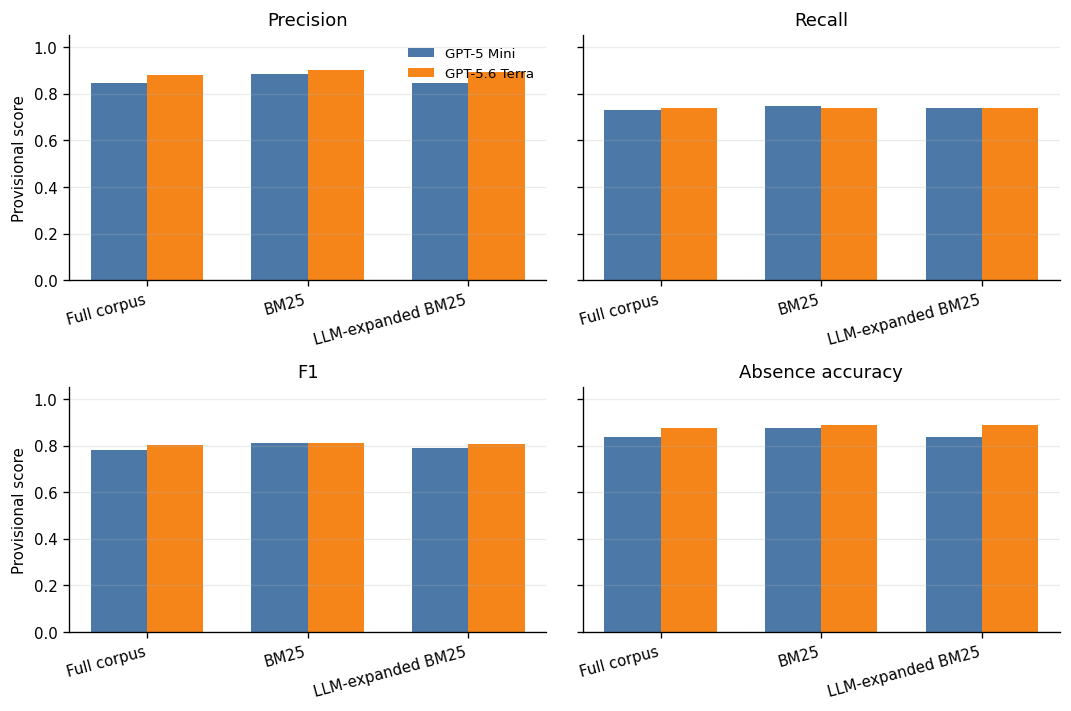

In [8]:
metric_names = ["precision", "recall", "f1", "abstention_accuracy"]
metric_labels = ["Precision", "Recall", "F1", "Absence accuracy"]

fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharey=True)
for ax, metric, title in zip(axes.flat, metric_names, metric_labels):
    width = 0.35
    positions = list(range(len(MODES)))
    for offset, model_name in zip((-width / 2, width / 2), MODELS.values()):
        subset = metrics_df[metrics_df["model"] == model_name]
        ax.bar(
            [position + offset for position in positions],
            subset[metric],
            width,
            label=model_name,
            color=COLORS[model_name],
        )
    ax.set_xticks(positions, list(MODES.values()), rotation=15, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
axes[0, 0].set_ylabel("Provisional score")
axes[1, 0].set_ylabel("Provisional score")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.tight_layout()
pdf_path = ANALYSIS_DIR / "preliminary-field-metrics.pdf"
png_path = ANALYSIS_DIR / "preliminary-field-metrics.png"
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(png_path)))

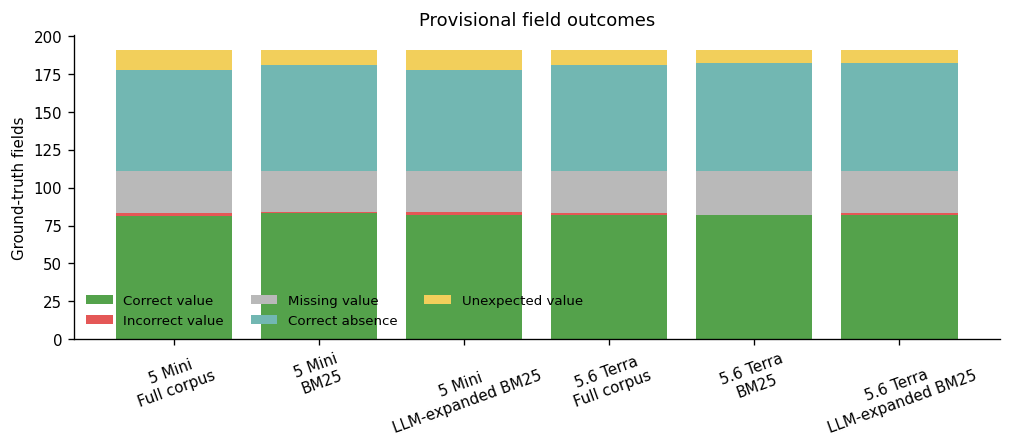

In [9]:
outcome_columns = [
    "correct_value",
    "incorrect_value",
    "missing_value",
    "correct_absence",
    "unexpected_value",
]
outcome_labels = [
    "Correct value",
    "Incorrect value",
    "Missing value",
    "Correct absence",
    "Unexpected value",
]
outcome_colors = ["#54A24B", "#E45756", "#B9B9B9", "#72B7B2", "#F2CF5B"]

fig, ax = plt.subplots(figsize=(8.5, 3.8))
bottom = pd.Series([0] * len(metrics_df))
for column, label, color in zip(outcome_columns, outcome_labels, outcome_colors):
    values = metrics_df.get(column, pd.Series([0] * len(metrics_df))).fillna(0)
    ax.bar(labels, values, bottom=bottom, label=label, color=color)
    bottom = bottom + values.reset_index(drop=True)
ax.set_ylabel("Ground-truth fields")
ax.set_title("Provisional field outcomes")
ax.tick_params(axis="x", rotation=20)
ax.legend(frameon=False, ncol=3, fontsize=8)
fig.tight_layout()
pdf_path = ANALYSIS_DIR / "field-outcomes.pdf"
png_path = ANALYSIS_DIR / "field-outcomes.png"
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(png_path)))

## 4. Documentation and citation checks

Mechanical citation validity requires:

1. the cited chunk ID exists in the frozen corpus;
2. the cited URL matches the chunk;
3. the chunk is target-site scoped; and
4. the exact quote occurs in the chunk after whitespace normalization.

This does **not** establish that the quote semantically proves the extracted claim. Semantic
citation validity still requires human annotation.

In [10]:
chunks = {
    item["chunk_id"]: item
    for item in (
        json.loads(line)
        for line in (CORPUS_DIR / "chunks.jsonl").read_text(encoding="utf-8").splitlines()
        if line.strip()
    )
}


def normalized_text(value: str) -> str:
    return re.sub(r"\s+", " ", value).strip().casefold()


citation_rows = []
documentation_rows = []
for model, mode in RUN_ORDER:
    documentation = runs[(model, mode)]["documentation"]
    valid_count = 0
    citation_count = 0
    for finding_index, finding in enumerate(documentation["findings"]):
        for citation in finding["citations"]:
            citation_count += 1
            chunk = chunks.get(citation["chunk_id"])
            valid = (
                chunk is not None
                and normalized_text(citation["url"]) == normalized_text(chunk["source_url"])
                and chunk["scope"] == "target_site"
                and normalized_text(citation["quote"]) in normalized_text(chunk["text"])
            )
            valid_count += int(valid)
            citation_rows.append({
                "model": MODELS[model],
                "mode": MODES[mode],
                "finding_index": finding_index,
                "chunk_id": citation["chunk_id"],
                "url": citation["url"],
                "quote": citation["quote"],
                "mechanically_valid": valid,
            })
    documentation_rows.append({
        "model": MODELS[model],
        "mode": MODES[mode],
        "accepted_findings": len(documentation["findings"]),
        "rejected_proposals": len(documentation["rejected"]),
        "unresolved_documentation_fields": len(documentation["unresolved"]),
        "selected_chunks": len(set(documentation["selected_chunk_ids"])),
        "citations": citation_count,
        "valid_citations": valid_count,
        "mechanical_citation_validity": valid_count / citation_count if citation_count else 0.0,
    })

citation_df = pd.DataFrame(citation_rows)
documentation_df = pd.DataFrame(documentation_rows)
citation_df.to_csv(ANALYSIS_DIR / "citation-checks.csv", index=False)
documentation_df.to_csv(ANALYSIS_DIR / "documentation-summary.csv", index=False)
display(documentation_df)

,model,mode,accepted_findings,rejected_proposals,unresolved_documentation_fields,selected_chunks,citations,valid_citations,mechanical_citation_validity
0,GPT-5 Mini,Full corpus,59,0,1,371,94,94,1.0
1,GPT-5 Mini,BM25,15,5,2,22,33,33,1.0
2,GPT-5 Mini,LLM-expanded BM25,19,3,2,34,33,33,1.0
3,GPT-5.6 Terra,Full corpus,12,1,4,371,22,22,1.0
4,GPT-5.6 Terra,BM25,14,1,2,22,38,38,1.0
5,GPT-5.6 Terra,LLM-expanded BM25,15,0,1,33,25,25,1.0


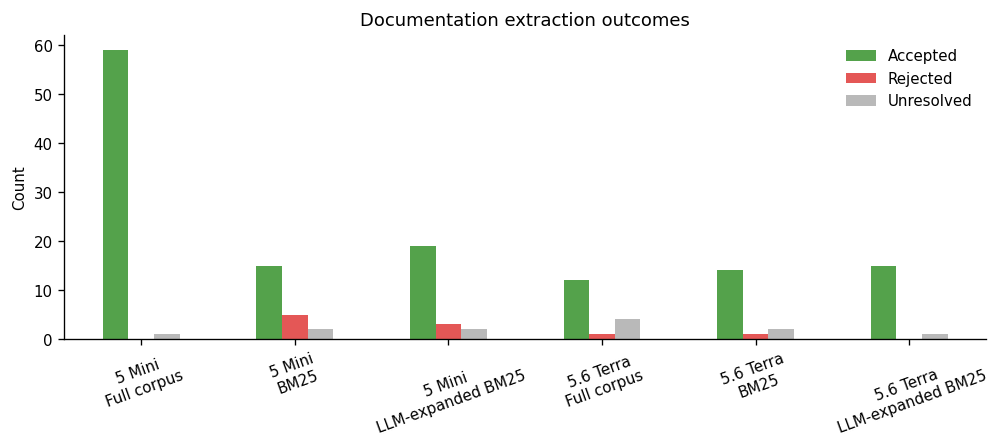

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))
doc_plot = documentation_df.set_index(["model", "mode"])[
    ["accepted_findings", "rejected_proposals", "unresolved_documentation_fields"]
]
doc_plot.index = labels
doc_plot.plot(
    kind="bar",
    ax=ax,
    color=["#54A24B", "#E45756", "#B9B9B9"],
)
ax.set_ylabel("Count")
ax.set_title("Documentation extraction outcomes")
ax.tick_params(axis="x", rotation=20)
ax.legend(["Accepted", "Rejected", "Unresolved"], frameon=False)
fig.tight_layout()
pdf_path = ANALYSIS_DIR / "documentation-outcomes.pdf"
png_path = ANALYSIS_DIR / "documentation-outcomes.png"
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(png_path)))

## 5. Field-level errors

The table below lists every provisional error. It is intended for debugging extraction and
ground-truth refinement, not as a final paper result.

In [12]:
errors = field_df[
    field_df["outcome"].isin(["incorrect_value", "missing_value", "unexpected_value"])
].copy()
errors.to_csv(ANALYSIS_DIR / "field-errors.csv", index=False)

error_counts = (
    errors.groupby(["model", "mode", "outcome"], observed=True)
    .size()
    .rename("count")
    .reset_index()
)
display(error_counts)
display(
    errors[
        [
            "model",
            "mode",
            "field_path",
            "expected_state",
            "expected_value_json",
            "actual_value_json",
            "outcome",
        ]
    ].head(40)
)

,model,mode,outcome,count
0,GPT-5 Mini,BM25,incorrect_value,1
1,GPT-5 Mini,BM25,missing_value,27
2,GPT-5 Mini,BM25,unexpected_value,10
3,GPT-5 Mini,Full corpus,incorrect_value,2
4,GPT-5 Mini,Full corpus,missing_value,28
5,GPT-5 Mini,Full corpus,unexpected_value,13
6,GPT-5 Mini,LLM-expanded BM25,incorrect_value,2
7,GPT-5 Mini,LLM-expanded BM25,missing_value,27
8,GPT-5 Mini,LLM-expanded BM25,unexpected_value,13
9,GPT-5.6 Terra,BM25,missing_value,29


,model,mode,field_path,expected_state,expected_value_json,actual_value_json,outcome
0,GPT-5 Mini,Full corpus,/aliases,value,"[""Anvil""]",[],missing_value
5,GPT-5 Mini,Full corpus,/slurm/unmapped_options,silent,,"[{""documented_name"": ""ACCESS account"", ""docume...",unexpected_value
10,GPT-5 Mini,Full corpus,/slurm/options/partition/required,value,true,false,incorrect_value
13,GPT-5 Mini,Full corpus,/slurm/options/nodes/required,silent,,false,unexpected_value
16,GPT-5 Mini,Full corpus,/slurm/options/cpus-per-task/required,silent,,false,unexpected_value
19,GPT-5 Mini,Full corpus,/slurm/options/time/required,silent,,false,unexpected_value
22,GPT-5 Mini,Full corpus,/slurm/partitions/wholenode/available,value,true,null,missing_value
24,GPT-5 Mini,Full corpus,/slurm/partitions/wholenode/maximum_walltime_s...,silent,,345600,unexpected_value
29,GPT-5 Mini,Full corpus,/slurm/partitions/wholenode/gpu_count_per_node,value,0,null,missing_value
32,GPT-5 Mini,Full corpus,/slurm/partitions/standard/available,value,true,null,missing_value


## 6. Preliminary summary

These statements are generated from the six run artifacts. They should be treated as descriptive
results until the ground truth receives human review and multiple repetitions quantify variance.

In [13]:
lowest_tokens = performance_df.loc[performance_df["total_tokens"].idxmin()]
lowest_latency = performance_df.loc[performance_df["total_seconds"].idxmin()]
best_f1 = metrics_df.loc[metrics_df["f1"].idxmax()]
best_absence = metrics_df.loc[metrics_df["abstention_accuracy"].idxmax()]

print(
    f"Lowest token use: {lowest_tokens['model']} / {lowest_tokens['mode']} "
    f"({int(lowest_tokens['total_tokens']):,} tokens)."
)
print(
    f"Lowest latency: {lowest_latency['model']} / {lowest_latency['mode']} "
    f"({lowest_latency['total_seconds']:.1f} seconds)."
)
print(
    f"Highest provisional F1: {best_f1['model']} / {best_f1['mode']} "
    f"({best_f1['f1']:.3f})."
)
print(
    f"Highest provisional expected-absence accuracy: "
    f"{best_absence['model']} / {best_absence['mode']} "
    f"({best_absence['abstention_accuracy']:.3f})."
)
print(f"All generated tables and PDF figures: {ANALYSIS_DIR}")

Lowest token use: GPT-5.6 Terra / BM25 (10,522 tokens).
Lowest latency: GPT-5.6 Terra / BM25 (18.8 seconds).
Highest provisional F1: GPT-5.6 Terra / BM25 (0.812).
Highest provisional expected-absence accuracy: GPT-5.6 Terra / BM25 (0.887).
All generated tables and PDF figures: /Users/saiful/ai-projects/hpc-site-preflight/artifacts/evaluation/anvil/preliminary-analysis
